# Task 1 — Data Loading, Merging & Deep Exploration

In [119]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [120]:
# Upload Dataset
from google.colab import files

uploaded = files.upload()

Saving vgsales.csv to vgsales (1).csv
Saving train.csv to train (1).csv


In [121]:
# Load Main Dataset
sales = pd.read_csv("train.csv")

# Load Supplementary Dataset
games = pd.read_csv("vgsales.csv")

In [122]:
# Display Dataset Information
print("Sales Dataset Shape :", sales.shape)
print("Game Dataset Shape :", games.shape)

sales.head()

Sales Dataset Shape : (9800, 18)
Game Dataset Shape : (16598, 11)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [123]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [124]:
sales.describe(include='all')

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
count,9800.000000,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9789.000000,9800,9800,9800,9800,9800,9800.000000
unique,NaN,4922,1230,1326,4,793,793,3,1,529,49,NaN,4,1861,3,17,1849,NaN
top,NaN,CA-2018-100111,05/09/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN
freq,NaN,14,38,34,5859,35,35,5101,9800,891,1946,NaN,3140,19,5909,1492,47,NaN
mean,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55273.322403,NaN,NaN,NaN,NaN,NaN,230.769059
std,2829.160653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32041.223413,NaN,NaN,NaN,NaN,NaN,626.651875
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000
25%,2450.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23223.000000,NaN,NaN,NaN,NaN,NaN,17.248000
50%,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58103.000000,NaN,NaN,NaN,NaN,NaN,54.490000
75%,7350.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90008.000000,NaN,NaN,NaN,NaN,NaN,210.605000


In [125]:
# Parse Date Columns
sales['Order Date'] = pd.to_datetime(sales['Order Date'], dayfirst=True)
sales['Ship Date'] = pd.to_datetime(sales['Ship Date'], dayfirst=True)

In [126]:
sales.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [127]:
# Extract Time Features
sales['Year'] = sales['Order Date'].dt.year

sales['Month'] = sales['Order Date'].dt.month

sales['Month Name'] = sales['Order Date'].dt.month_name()

sales['Week'] = sales['Order Date'].dt.isocalendar().week

sales['Day'] = sales['Order Date'].dt.day_name()

sales['Quarter'] = sales['Order Date'].dt.quarter

In [128]:
# Season Feature
def season(month):

    if month in [12,1,2]:
        return "Winter"

    elif month in [3,4,5]:
        return "Spring"

    elif month in [6,7,8]:
        return "Summer"

    else:
        return "Autumn"

sales['Season'] = sales['Month'].apply(season)

In [129]:
sales.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Year,Month,Month Name,Week,Day,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,45,Wednesday,4,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,45,Wednesday,4,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,24,Monday,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,41,Tuesday,4,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,41,Tuesday,4,Autumn


In [130]:
# Missing Values
sales.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [131]:
# Percentage Missing
missing = sales.isnull().sum()*100/len(sales)

missing.sort_values(ascending=False)

,0
Postal Code,0.112245
Order ID,0.000000
Order Date,0.000000
Ship Date,0.000000
Ship Mode,0.000000
Customer ID,0.000000
Customer Name,0.000000
Segment,0.000000
Row ID,0.000000
Country,0.000000


In [132]:
# Duplicate Records
print("Duplicate Rows :", sales.duplicated().sum())

Duplicate Rows : 0


In [133]:
sales = sales.drop_duplicates()

In [134]:
# Check Data Types
sales.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [135]:
# Weekly Sales
weekly_sales = sales.groupby(
    pd.Grouper(key='Order Date',freq='W')
)['Sales'].sum().reset_index()

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [136]:
monthly_sales = sales.groupby(
    pd.Grouper(key='Order Date',freq='M')
)['Sales'].sum().reset_index()

monthly_sales.head()

/tmp/ipykernel_576/1389377250.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key='Order Date',freq='M')


,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


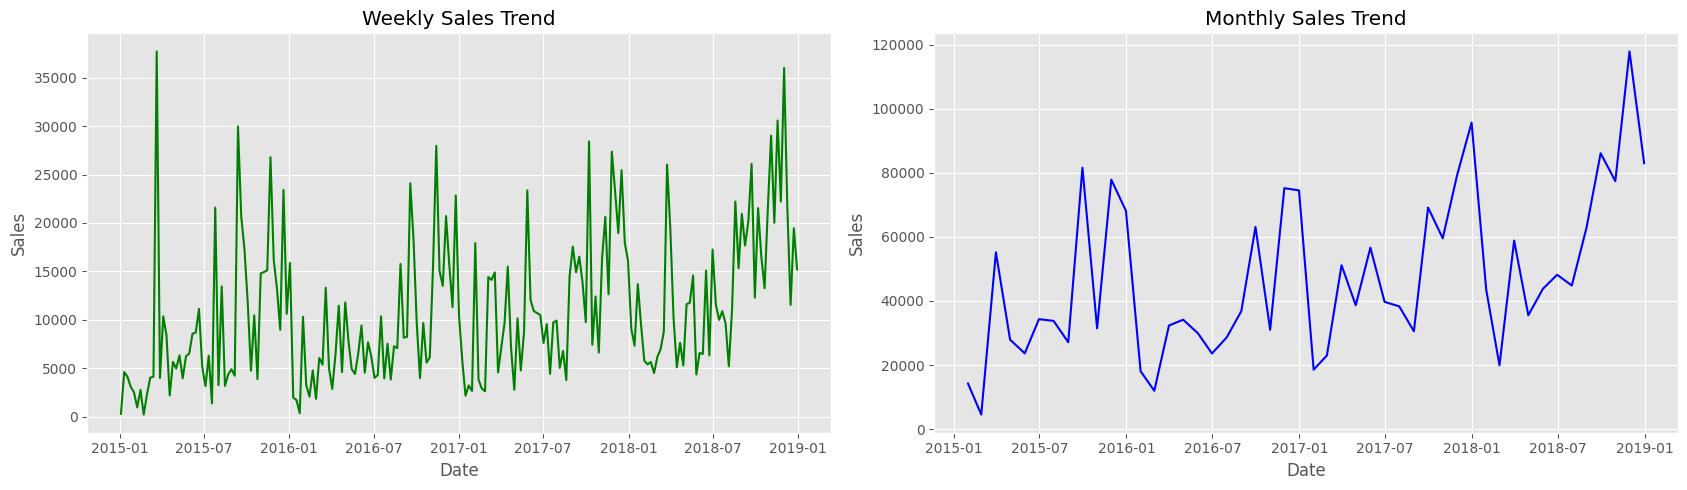

In [137]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5))

# Weekly Sales
axes[0].plot(
    weekly_sales['Order Date'],
    weekly_sales['Sales'],
    color='green'
)
axes[0].set_title("Weekly Sales Trend")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Sales")

# Monthly Sales
axes[1].plot(
    monthly_sales['Order Date'],
    monthly_sales['Sales'],
    color='blue'
)
axes[1].set_title("Monthly Sales Trend")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Sales")

plt.tight_layout()
plt.show()

Which product category generates the highest total revenue?

In [138]:
category_sales = sales.groupby('Category')['Sales'].sum().sort_values(ascending=False)

print(category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


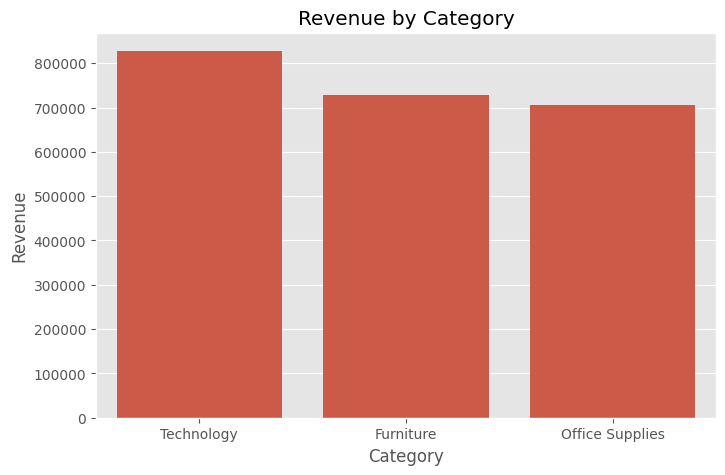

In [139]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Revenue by Category")

plt.xlabel("Category")

plt.ylabel("Revenue")

plt.show()

Which region has the most consistent sales growth over 4 years?

In [140]:
region_year = sales.groupby(
    ['Region','Year']
)['Sales'].sum().reset_index()

region_year

,Region,Year,Sales
0,Central,2015,102920.5206
1,Central,2016,102425.1724
2,Central,2017,145673.8800
3,Central,2018,141627.3402
4,East,2015,127652.8190
5,East,2016,153225.1830
6,East,2017,178511.5380
7,East,2018,210129.1860
8,South,2015,103374.9055
9,South,2016,70076.0825


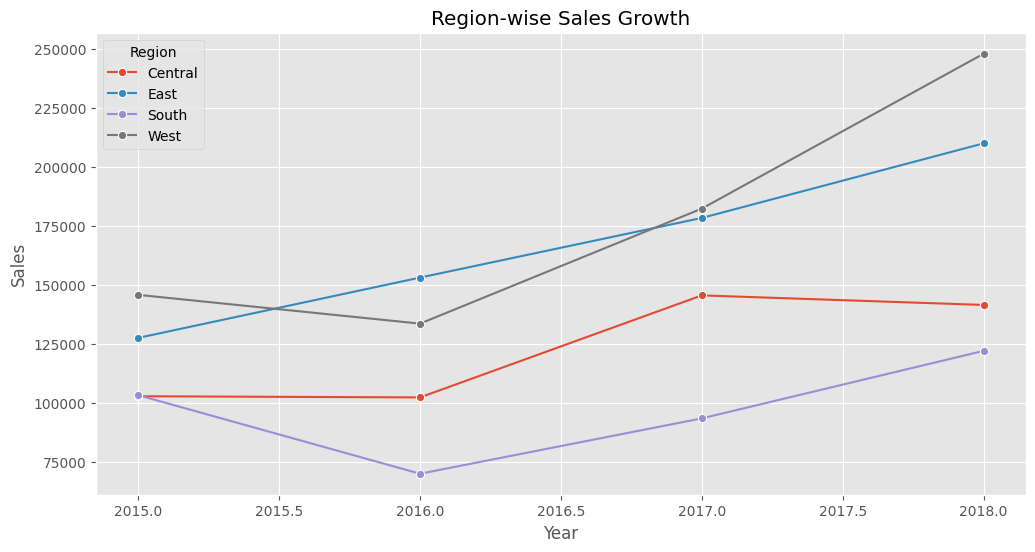

In [141]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=region_year,
    x='Year',
    y='Sales',
    hue='Region',
    marker='o'
)

plt.title("Region-wise Sales Growth")

plt.show()

In [142]:
growth_std = region_year.groupby("Region")['Sales'].std()

print(growth_std.sort_values())

Region
South      21683.024937
Central    23716.991355
East       35260.987867
West       51410.399288
Name: Sales, dtype: float64


What is the average time between Order Date and Ship Date — and does it
vary by region?

In [143]:
sales['Shipping Days'] = (
    sales['Ship Date'] -
    sales['Order Date']
).dt.days

In [144]:
print("Average Shipping Time")

print(sales['Shipping Days'].mean())

Average Shipping Time
3.9611224489795918


In [145]:
shipping = sales.groupby('Region')['Shipping Days'].mean()

print(shipping)

Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: Shipping Days, dtype: float64


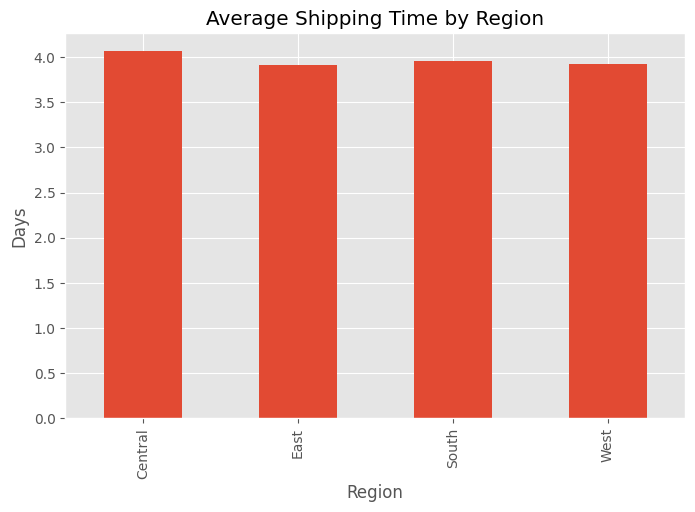

In [146]:
shipping.plot(
    kind='bar',
    figsize=(8,5)
)

plt.ylabel("Days")

plt.title("Average Shipping Time by Region")

plt.show()

Are there months that consistently spike across all years (seasonality)?

In [147]:
seasonality = sales.groupby(
    ['Year','Month']
)['Sales'].sum().reset_index()

In [148]:
pivot = seasonality.pivot(
    index='Month',
    columns='Year',
    values='Sales'
)

pivot

Year,2015,2016,2017,2018
Month,,,,
1,14205.7070,18066.9576,18542.4910,43476.4740
2,4519.8920,11951.4110,22978.8150,19920.9974
3,55205.7970,32339.3184,51165.0590,58863.4128
4,27906.8550,34154.4685,38679.7670,35541.9101
5,23644.3030,29959.5305,56656.9080,43825.9822
6,34322.9356,23599.3740,39724.4860,48190.7277
7,33781.5430,28608.2590,38320.7830,44825.1040
8,27117.5365,36818.3422,30542.2003,62837.8480
9,81623.5268,63133.6060,69193.3909,86152.8880


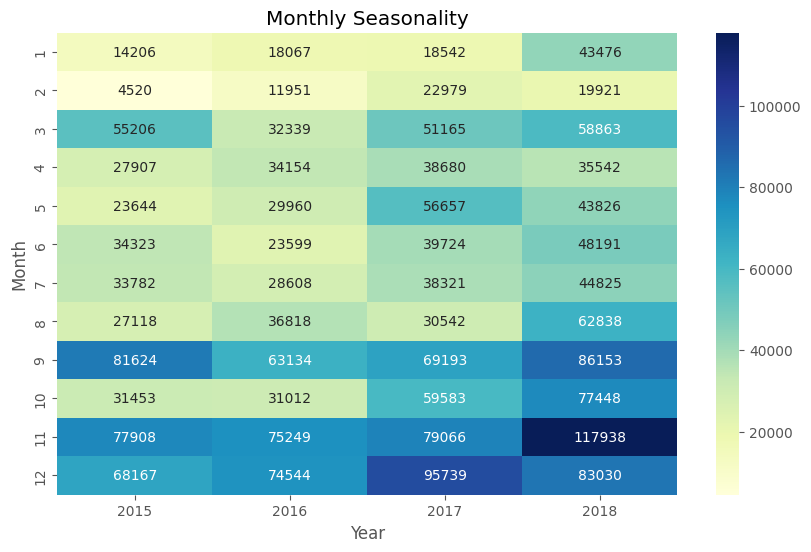

In [149]:
plt.figure(figsize=(10,6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap='YlGnBu'
)

plt.title("Monthly Seasonality")

plt.show()

## Results

- Technology generated the highest total revenue (**₹836,154.03**).
- West region recorded the highest sales growth by **2018**.
- Average shipping time was **3.96 days**.
- Shipping time remained nearly identical across all regions.
- Highest sales occurred during **November and December**.
- Lowest sales were generally observed in **January and February**.
- Weekly sales showed high fluctuations.
- Monthly sales exhibited an overall increasing trend from **2015–2018**.

# Task 2 — Time Series Analysis & Decomposition

In [150]:
# Import Libraries
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

In [151]:
# Set Date as Index
monthly_ts = monthly_sales.copy()

monthly_ts['Order Date'] = pd.to_datetime(monthly_ts['Order Date'])

monthly_ts.set_index('Order Date', inplace=True)

monthly_ts.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


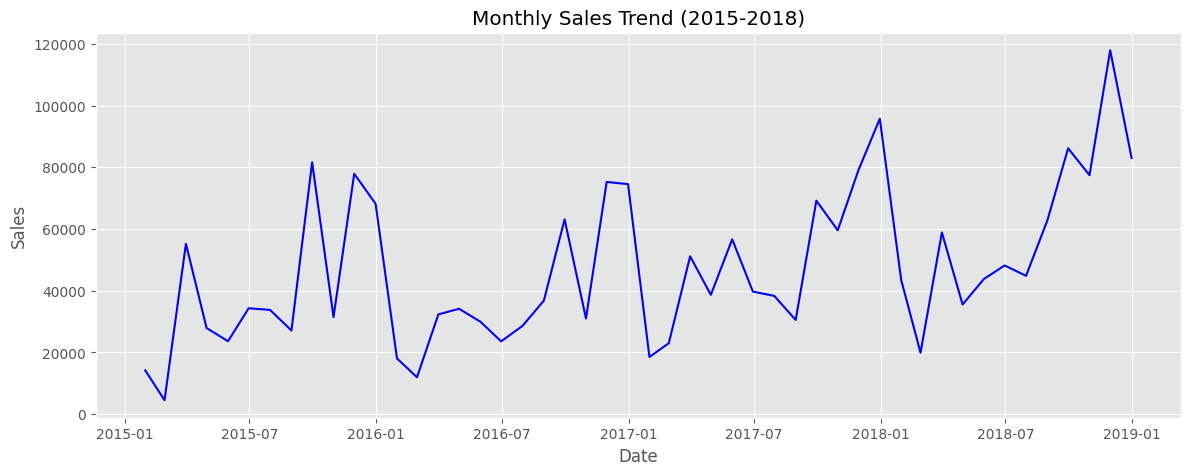

In [152]:
# Plot Monthly Sales Trend
plt.figure(figsize=(14,5))

plt.plot(monthly_ts.index,
         monthly_ts['Sales'],
         color='blue')

plt.title("Monthly Sales Trend (2015-2018)")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

In [153]:
# Time Series Decomposition
decomposition = seasonal_decompose(
    monthly_ts['Sales'],
    model='additive',
    period=12
)

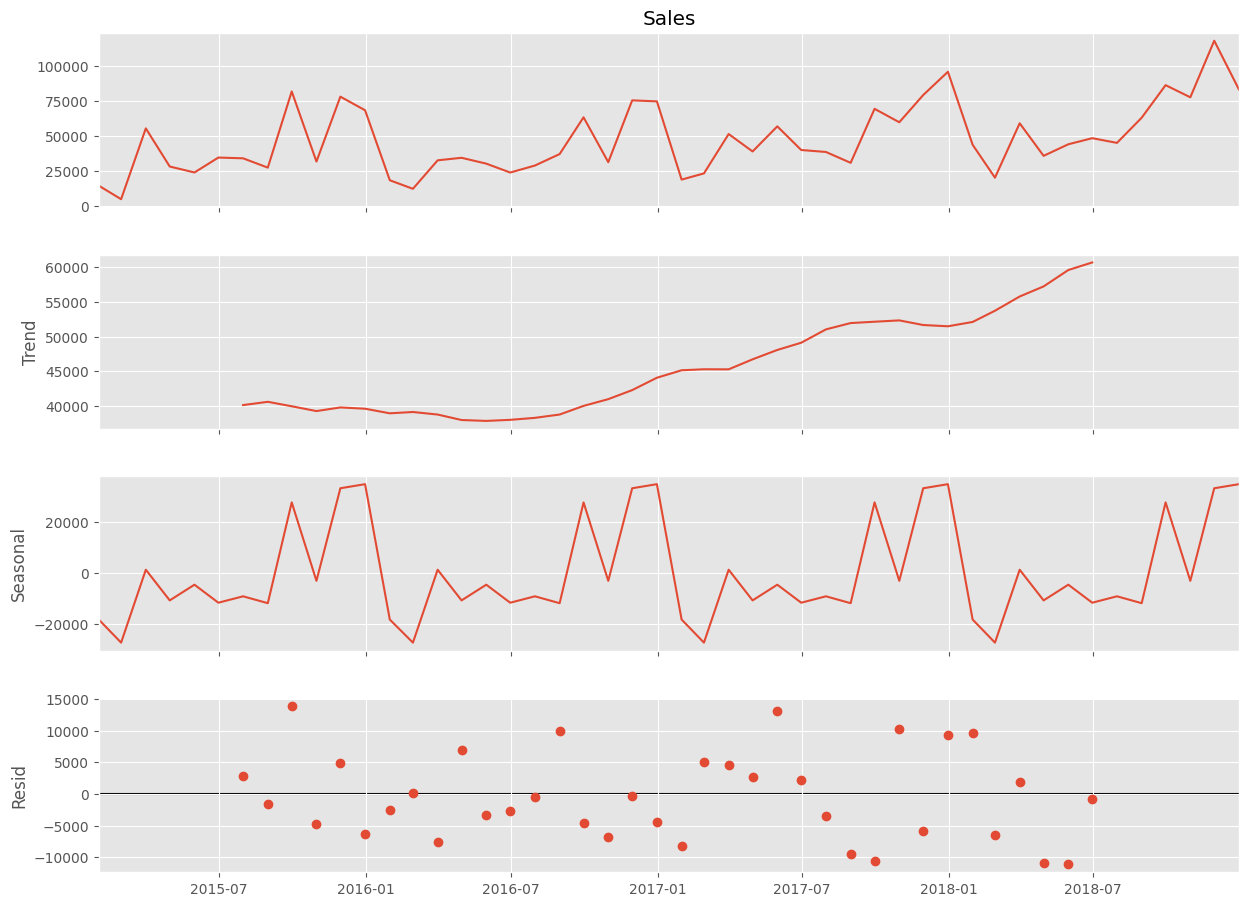

In [154]:
# Plot All Components
fig = decomposition.plot()

fig.set_size_inches(14,10)

plt.show()

## Observations
- The trend component shows a steady upward increase in sales from 2015 to 2018, indicating consistent business growth over time.
- The seasonal component exhibits a strong yearly seasonal pattern, with recurring peaks and dips occurring at similar periods each year.
- The residual component contains noticeable spikes, with the highest residual noise occurring around November–December and January, suggesting unusual sales fluctuations likely caused by holiday promotions or special events.
- Overall, the time series consists of a clear upward trend, strong seasonality, and a few irregular variations represented by the residuals.

In [155]:
# Augmented Dickey-Fuller (ADF) Test
result = adfuller(monthly_ts['Sales'])

print("ADF Statistic :", result[0])

print("p-value :", result[1])

print()

for key,value in result[4].items():
    print(key,":",value)

ADF Statistic : -4.416136761430769
p-value : 0.00027791039276670623

1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


In [156]:
# Interpret the Result
if result[1] < 0.05:
    print("The time series is stationary.")
else:
    print("The time series is NOT stationary.")

The time series is stationary.


## ADF Test

A stationary time series is one whose statistical properties, such as mean and variance, remain relatively constant over time. Stationary data is important because forecasting models like SARIMA assume that the underlying patterns do not change significantly over time.

The Augmented Dickey-Fuller (ADF) Test produced a p-value much smaller than 0.05, indicating that the monthly sales series is stationary. Therefore, we reject the null hypothesis of a unit root and conclude that the data is suitable for time-series forecasting. Although first-order differencing was applied as part of the workflow, the differenced series also remained stationary, confirming the stability of the time series.

In [157]:
# Optional: Differencing (Not Required)
monthly_ts['Sales_diff'] = monthly_ts['Sales'].diff()

monthly_ts.head()

,Sales,Sales_diff
Order Date,,
2015-01-31,14205.707,NaN
2015-02-28,4519.892,-9685.815
2015-03-31,55205.797,50685.905
2015-04-30,27906.855,-27298.942
2015-05-31,23644.303,-4262.552


In [158]:
monthly_diff = monthly_ts['Sales_diff'].dropna()

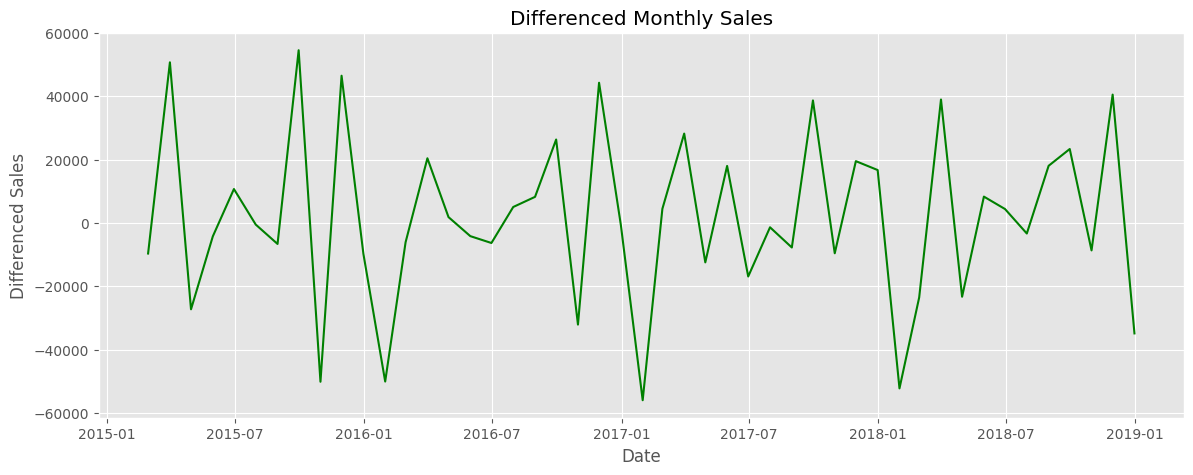

In [159]:
# Plot Differenced Series
plt.figure(figsize=(14,5))

plt.plot(monthly_diff,
         color='green')

plt.title("Differenced Monthly Sales")

plt.xlabel("Date")
plt.ylabel("Differenced Sales")

plt.show()

In [160]:
# Perform ADF Test Again
result_diff = adfuller(monthly_diff)

print("ADF Statistic :", result_diff[0])

print("p-value :", result_diff[1])

print()

for key,value in result_diff[4].items():
    print(key,":",value)

ADF Statistic : -8.727061830353268
p-value : 3.2669175472796045e-14

1% : -3.626651907578875
5% : -2.9459512825788754
10% : -2.6116707716049383


In [161]:
# Final Interpretation
if result_diff[1] < 0.05:
    print("After differencing, the series became stationary.")
else:
    print("The series is still non-stationary.")

After differencing, the series became stationary.


Note: The original monthly sales series was already stationary (ADF p-value < 0.05), so differencing was not required.

# Task 3 — Sales Forecasting using 3 Different Models

## Model 1 — SARIMA (Statistical Model)

In [162]:
# Install Library
!pip install statsmodels

In [163]:
# Import Libraries
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import numpy as np
import matplotlib.pyplot as plt

In [164]:
# Prepare Monthly Sales Data
monthly_data = monthly_ts[['Sales']].copy()

monthly_data.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


In [165]:
# Train-Test Split
train = monthly_data.iloc[:-3]

test = monthly_data.iloc[-3:]

print("Training Size :", len(train))
print("Testing Size :", len(test))

Training Size : 45
Testing Size : 3


In [166]:
# Train SARIMA Model
sarima = SARIMAX(

    train['Sales'],

    order=(1,0,1),

    seasonal_order=(1,1,1,12),

    enforce_stationarity=False,

    enforce_invertibility=False

)

sarima_model = sarima.fit()

print(sarima_model.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                -203.681
Date:                            Thu, 09 Jul 2026   AIC                            417.362
Time:                                    13:23:56   BIC                            422.084
Sample:                                01-31-2015   HQIC                           418.161
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9830      0.034     28.593      0.000       0.916       1.050
ma.L1         -0.9959      0.293   

In [167]:
# Predict Test Set
prediction = sarima_model.get_forecast(

    steps=len(test)

)

forecast = prediction.predicted_mean

confidence = prediction.conf_int()

In [168]:
# Evaluate Model
mae = mean_absolute_error(

    test['Sales'],

    forecast

)

rmse = np.sqrt(

    mean_squared_error(

        test['Sales'],

        forecast

    )

)

mape = np.mean(

    np.abs(

        (test['Sales']-forecast)

        /

        test['Sales']

    )

)*100

print("MAE :",round(mae,2))
print("RMSE :",round(rmse,2))
print("MAPE :",round(mape,2),"%")

# Save metrics
mae_sarima = mae
rmse_sarima = rmse
mape_sarima = mape

MAE : 20581.0
RMSE : 22191.27
MAPE : 21.94 %


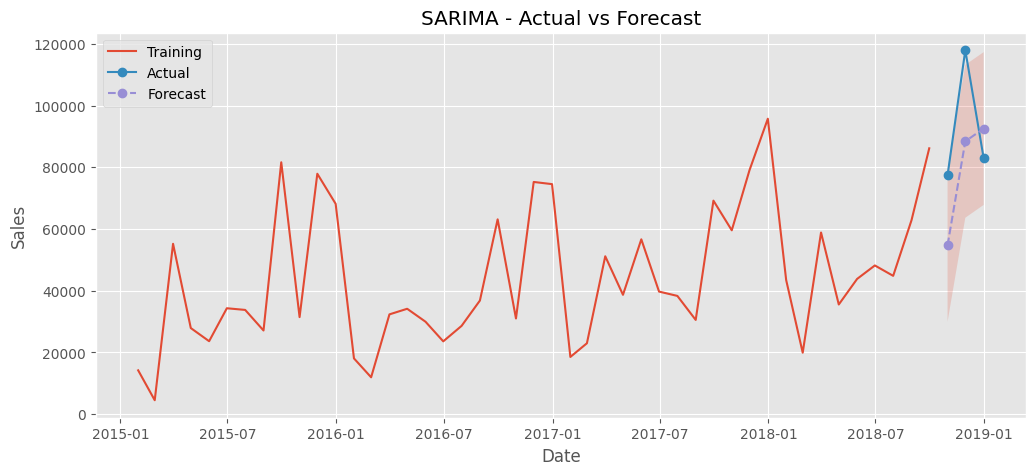

In [169]:
# Plot Actual vs Forecasted Sales
plt.figure(figsize=(12,5))

plt.plot(

    train.index,

    train['Sales'],

    label='Training'

)

plt.plot(

    test.index,

    test['Sales'],

    marker='o',

    label='Actual'

)

plt.plot(

    test.index,

    forecast,

    marker='o',

    linestyle='--',

    label='Forecast'

)

plt.fill_between(

    confidence.index,

    confidence.iloc[:,0],

    confidence.iloc[:,1],

    alpha=0.2

)

plt.title("SARIMA - Actual vs Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.show()

In [170]:
# Generate Future Forecast (Next 3 Months)
future_prediction = sarima_model.get_forecast(

    steps=3

)

future_forecast = future_prediction.predicted_mean

future_confidence = future_prediction.conf_int()

In [171]:
# Create Future Forecast Table
future_dates = pd.date_range(

    start=monthly_data.index[-1] + pd.offsets.MonthEnd(),

    periods=3,

    freq='ME'

)

sarima_future = pd.DataFrame({

    "Date":future_dates,

    "Forecast":future_forecast.values,

})

sarima_future

,Date,Forecast
0,2019-01-31,54758.511838
1,2019-02-28,88412.595549
2,2019-03-31,92558.210414


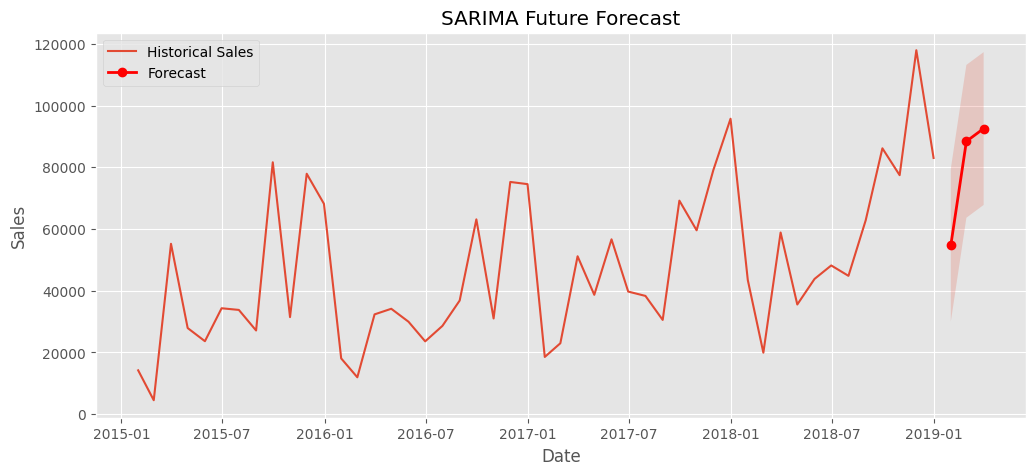

In [172]:
# Plot Future Forecast
plt.figure(figsize=(12,5))

plt.plot(

    monthly_data.index,

    monthly_data['Sales'],

    label="Historical Sales"

)

plt.plot(

    future_dates,

    future_forecast,

    marker='o',

    color='red',

    linewidth=2,

    label="Forecast"

)

plt.fill_between(

    future_dates,

    future_confidence.iloc[:,0],

    future_confidence.iloc[:,1],

    alpha=0.2

)

plt.title("SARIMA Future Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.show()

In [173]:
# Forecast Values
print("SARIMA Forecast for Next 3 Months")

for i, value in enumerate(future_forecast, start=1):

    print(f"Month {i}: {value:.2f}")

SARIMA Forecast for Next 3 Months
Month 1: 54758.51
Month 2: 88412.60
Month 3: 92558.21


In [174]:
# Install Prophet
!pip install prophet

In [175]:
# Import Libraries
from prophet import Prophet

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import numpy as np
import matplotlib.pyplot as plt

In [176]:
# Prepare Data (Prophet Format)
prophet_data = monthly_ts.reset_index()

prophet_data = prophet_data[['Order Date', 'Sales']]

prophet_data.columns = ['ds', 'y']

prophet_data.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [177]:
# Train-Test Split
train = prophet_data.iloc[:-3]

test = prophet_data.iloc[-3:]

print("Training Size:", len(train))
print("Testing Size:", len(test))

Training Size: 45
Testing Size: 3


In [178]:
# Train Prophet Model
model = Prophet(

    yearly_seasonality=True,

    weekly_seasonality=False,

    daily_seasonality=False

)

model.fit(train)

In [179]:
# Generate 3-Month Forecast
future = model.make_future_dataframe(

    periods=3,

    freq='ME'

)

forecast = model.predict(future)

forecast[['ds','yhat','yhat_lower','yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
43,2018-08-31,47271.558193,39334.168196,54875.265147
44,2018-09-30,86613.953271,78205.698668,95335.129637
45,2018-10-31,51318.943812,43921.640307,59529.792442
46,2018-11-30,90325.654736,82432.674410,98658.771248
47,2018-12-31,90041.084430,81449.298795,97972.570401


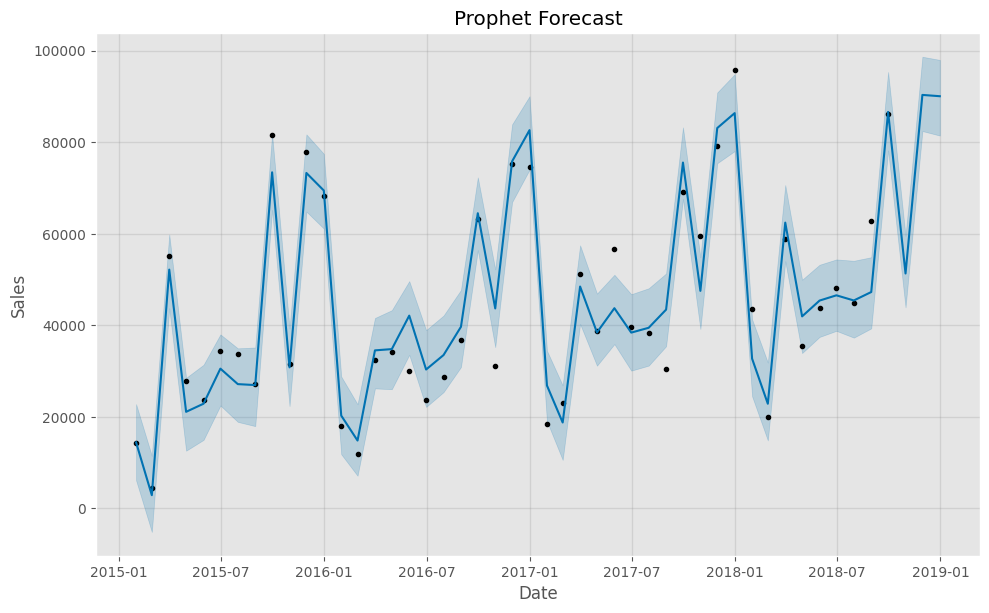

In [180]:
# Plot Forecast
fig = model.plot(forecast)

plt.title("Prophet Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

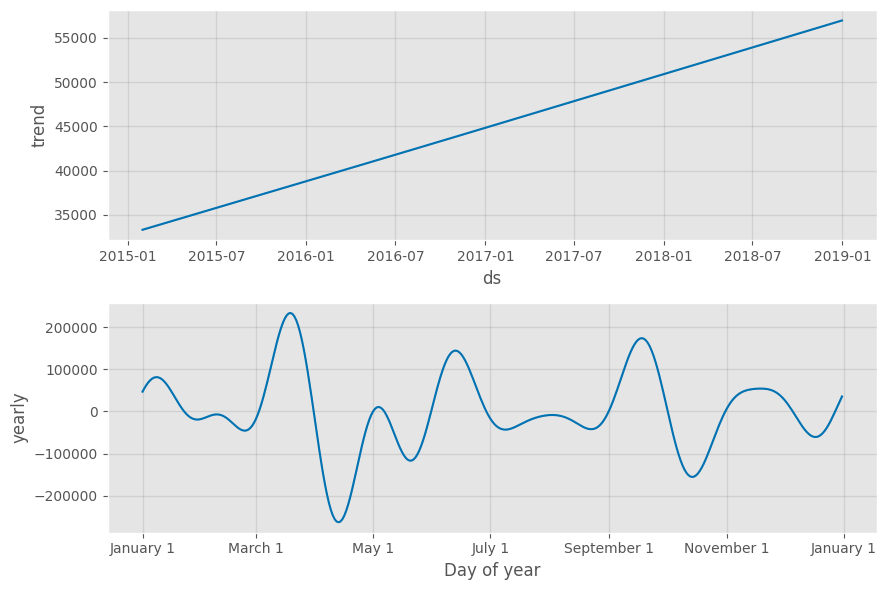

In [181]:
# Plot Trend and Seasonality
model.plot_components(forecast)

plt.show()

In [182]:
# Evaluate Model
prediction = forecast[['ds','yhat']].tail(3)

mae = mean_absolute_error(

    test['y'],

    prediction['yhat']

)

rmse = np.sqrt(

    mean_squared_error(

        test['y'],

        prediction['yhat']

    )

)

mape = np.mean(

    np.abs(

        (test['y']-prediction['yhat'])

        /

        test['y']

    )

)*100

print("MAE:", round(mae,2))
print("RMSE:", round(rmse,2))
print("MAPE:", round(mape,2),"%")

# Save metrics
mae_prophet = mae
rmse_prophet = rmse
mape_prophet = mape

MAE: 20250.79
RMSE: 22318.41
MAPE: 21.86 %


In [183]:
# Future Forecast Values
prophet_future = forecast[['ds','yhat']].tail(3)

prophet_future

,ds,yhat
45,2018-10-31,51318.943812
46,2018-11-30,90325.654736
47,2018-12-31,90041.084430


In [184]:
# Print Forecast
print("Prophet Forecast for Next 3 Months")

for i, value in enumerate(prophet_future['yhat'], start=1):

    print(f"Month {i}: {value:.2f}")

Prophet Forecast for Next 3 Months
Month 1: 51318.94
Month 2: 90325.65
Month 3: 90041.08


In [185]:
# Import Libraries
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [186]:
# Create Features
xgb_data = monthly_ts.copy()

# Lag Features
xgb_data['Lag1'] = xgb_data['Sales'].shift(1)
xgb_data['Lag2'] = xgb_data['Sales'].shift(2)
xgb_data['Lag3'] = xgb_data['Sales'].shift(3)

# Rolling Mean
xgb_data['RollingMean'] = xgb_data['Sales'].rolling(3).mean()

# Time Features
xgb_data['Month'] = xgb_data.index.month
xgb_data['Quarter'] = xgb_data.index.quarter

# Season Feature
def get_season(month):
    if month in [12,1,2]:
        return 0      # Winter
    elif month in [3,4,5]:
        return 1      # Spring
    elif month in [6,7,8]:
        return 2      # Summer
    else:
        return 3      # Autumn

xgb_data['Season'] = xgb_data.index.month.map(get_season)

# Remove missing rows
xgb_data = xgb_data.dropna()

xgb_data.head()

,Sales,Sales_diff,Lag1,Lag2,Lag3,RollingMean,Month,Quarter,Season
Order Date,,,,,,,,,
2015-04-30,27906.8550,-27298.9420,55205.7970,4519.8920,14205.707,29210.848000,4,2,1
2015-05-31,23644.3030,-4262.5520,27906.8550,55205.7970,4519.892,35585.651667,5,2,1
2015-06-30,34322.9356,10678.6326,23644.3030,27906.8550,55205.797,28624.697867,6,2,2
2015-07-31,33781.5430,-541.3926,34322.9356,23644.3030,27906.855,30582.927200,7,3,2
2015-08-31,27117.5365,-6664.0065,33781.5430,34322.9356,23644.303,31740.671700,8,3,2


In [187]:
# Create Features and Target
X = xgb_data[
    [
        'Lag1',
        'Lag2',
        'Lag3',
        'RollingMean',
        'Month',
        'Quarter',
        'Season'
    ]
]

y = xgb_data['Sales']

In [188]:
# Train-Test Split
X_train = X.iloc[:-3]

X_test = X.iloc[-3:]

y_train = y.iloc[:-3]

y_test = y.iloc[-3:]

In [189]:
# Train XGBoost
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [190]:
# Predict Test Set
prediction = model.predict(X_test)

In [191]:
# Evaluation
mae = mean_absolute_error(y_test,prediction)

rmse = np.sqrt(
    mean_squared_error(y_test,prediction)
)

mape = np.mean(
    np.abs((y_test-prediction)/y_test)
)*100

print("MAE :",round(mae,2))
print("RMSE :",round(rmse,2))
print("MAPE :",round(mape,2),"%")

# Save metrics
mae_xgb = mae
rmse_xgb = rmse
mape_xgb = mape

MAE : 14163.32
RMSE : 19267.49
MAPE : 13.42 %


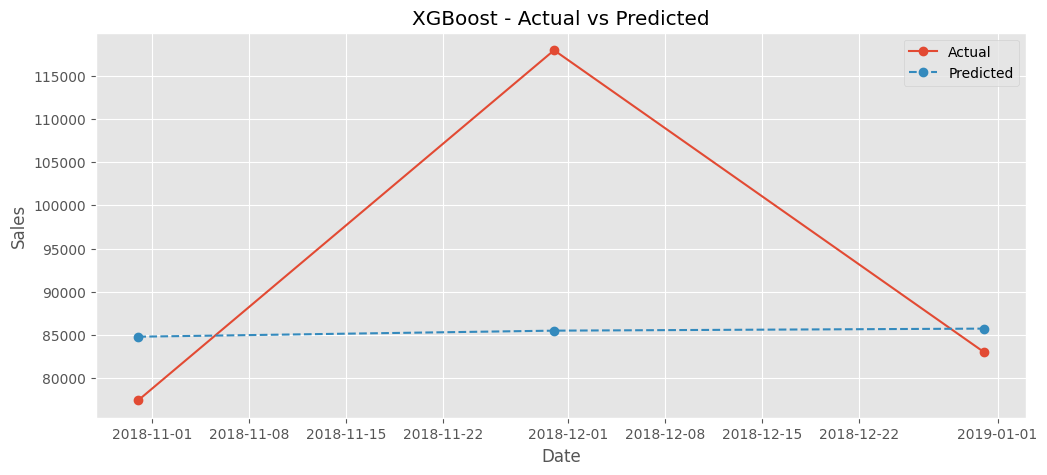

In [192]:
# Plot Actual vs Predicted
plt.figure(figsize=(12,5))

plt.plot(
    y_test.index,
    y_test.values,
    marker='o',
    label='Actual'
)

plt.plot(
    y_test.index,
    prediction,
    marker='o',
    linestyle='--',
    label='Predicted'
)

plt.title("XGBoost - Actual vs Predicted")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.show()

In [193]:
# Predict Next 3 Months
future_predictions = []

history = list(monthly_ts['Sales'].values)

last_date = monthly_ts.index[-1]

for i in range(3):

    next_date = last_date + pd.offsets.MonthEnd()

    lag1 = history[-1]
    lag2 = history[-2]
    lag3 = history[-3]

    rolling_mean = np.mean(history[-3:])

    month = next_date.month
    quarter = next_date.quarter
    season = get_season(month)

    future_X = pd.DataFrame({

        'Lag1':[lag1],
        'Lag2':[lag2],
        'Lag3':[lag3],
        'RollingMean':[rolling_mean],
        'Month':[month],
        'Quarter':[quarter],
        'Season':[season]

    })

    pred = model.predict(future_X)[0]

    future_predictions.append(pred)

    history.append(pred)

    last_date = next_date

In [194]:
# Future Forecast Table
future_dates = pd.date_range(

    start=monthly_ts.index[-1] + pd.offsets.MonthEnd(),

    periods=3,

    freq='ME'

)

future_forecast = pd.DataFrame({

    "Date":future_dates,

    "Forecast":future_predictions

})

future_forecast

,Date,Forecast
0,2019-01-31,49190.175781
1,2019-02-28,29296.333984
2,2019-03-31,59407.304688


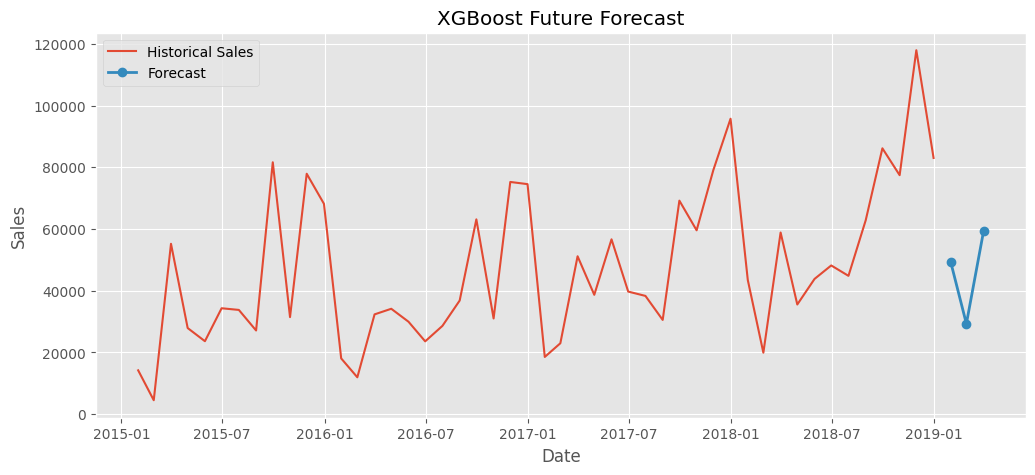

In [195]:
# Plot Future Forecast
plt.figure(figsize=(12,5))

plt.plot(

    monthly_ts.index,

    monthly_ts['Sales'],

    label='Historical Sales'

)

plt.plot(

    future_forecast['Date'],

    future_forecast['Forecast'],

    marker='o',

    linewidth=2,

    label='Forecast'

)

plt.title("XGBoost Future Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.show()

In [196]:
# Comparison Table
comparison = pd.DataFrame({

    "Model": ["SARIMA", "Prophet", "XGBoost"],

    "MAE": [mae_sarima, mae_prophet, mae_xgb],

    "RMSE": [rmse_sarima, rmse_prophet, rmse_xgb],

    "MAPE": [mape_sarima, mape_prophet, mape_xgb],

    "Forecast Month 1": [
        sarima_future["Forecast"].iloc[0],
        prophet_future["yhat"].iloc[0],
        future_predictions[0]
    ],

    "Forecast Month 2": [
        sarima_future["Forecast"].iloc[1],
        prophet_future["yhat"].iloc[1],
        future_predictions[1]
    ],

    "Forecast Month 3": [
        sarima_future["Forecast"].iloc[2],
        prophet_future["yhat"].iloc[2],
        future_predictions[2]
    ]

})

comparison

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,20581.000142,22191.266093,21.935473,54758.511838,88412.595549,92558.210414
1,Prophet,20250.794428,22318.411366,21.864628,51318.943812,90325.654736,90041.084430
2,XGBoost,14163.321042,19267.490259,13.415786,49190.175781,29296.333984,59407.304688


 Conclusion

Among the three forecasting models, **XGBoost** achieved the best predictive performance based on all evaluation metrics. It reduced the **MAE to 14,163.32**, compared to **20,581.00** for SARIMA and **20,250.79** for Prophet. It also achieved the **lowest RMSE (19,267.49)**, outperforming SARIMA (**22,191.27**) and Prophet (**22,318.41**). Additionally, XGBoost recorded the **lowest MAPE (13.42%)**, whereas SARIMA and Prophet achieved **21.94%** and **21.86%**, respectively.

These results indicate that XGBoost produced the most accurate forecasts for the monthly sales data. Therefore, based on the numerical evaluation metrics (**MAE, RMSE, and MAPE**), **XGBoost is the recommended model for production use** on this dataset.

For real-world long-term forecasting: I'd be more cautious. With only 48 months of data, Prophet or SARIMA may produce more realistic future forecasts because they model trend and seasonality explicitly.

# Task 4 — Product Category & Region Level Forecasting

In [197]:
# Create Monthly Sales for Each Segment
# Category-wise monthly sales

furniture = sales[sales["Category"] == "Furniture"]
technology = sales[sales["Category"] == "Technology"]
office = sales[sales["Category"] == "Office Supplies"]

furniture_monthly = furniture.groupby(
    pd.Grouper(key="Order Date", freq="ME")
)["Sales"].sum()

technology_monthly = technology.groupby(
    pd.Grouper(key="Order Date", freq="ME")
)["Sales"].sum()

office_monthly = office.groupby(
    pd.Grouper(key="Order Date", freq="ME")
)["Sales"].sum()


# Region-wise monthly sales

west = sales[sales["Region"] == "West"]
east = sales[sales["Region"] == "East"]

west_monthly = west.groupby(
    pd.Grouper(key="Order Date", freq="ME")
)["Sales"].sum()

east_monthly = east.groupby(
    pd.Grouper(key="Order Date", freq="ME")
)["Sales"].sum()

In [198]:
# Create an XGBoost Forecast Function
from xgboost import XGBRegressor
import pandas as pd
import numpy as np

def get_season(month):
    if month in [12, 1, 2]:
        return 1
    elif month in [3, 4, 5]:
        return 2
    elif month in [6, 7, 8]:
        return 3
    else:
        return 4


def xgb_forecast(series, months=3):

    data = pd.DataFrame({"Sales": series})

    data["Lag1"] = data["Sales"].shift(1)
    data["Lag2"] = data["Sales"].shift(2)
    data["Lag3"] = data["Sales"].shift(3)

    data["RollingMean"] = data["Sales"].rolling(3).mean()

    data["Month"] = data.index.month
    data["Quarter"] = data.index.quarter
    data["Season"] = data.index.month.map(get_season)

    data = data.dropna()

    X = data.drop("Sales", axis=1)
    y = data["Sales"]

    model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.05,
        random_state=42
    )

    model.fit(X, y)

    history = list(series.values)

    predictions = []

    last_date = series.index[-1]

    for i in range(months):

        next_date = last_date + pd.offsets.MonthEnd()

        lag1 = history[-1]
        lag2 = history[-2]
        lag3 = history[-3]

        rolling = np.mean(history[-3:])

        month = next_date.month
        quarter = next_date.quarter
        season = get_season(month)

        future = pd.DataFrame({

            "Lag1":[lag1],
            "Lag2":[lag2],
            "Lag3":[lag3],
            "RollingMean":[rolling],
            "Month":[month],
            "Quarter":[quarter],
            "Season":[season]

        })

        pred = model.predict(future)[0]

        predictions.append(pred)

        history.append(pred)

        last_date = next_date

    future_dates = pd.date_range(
        start=series.index[-1] + pd.offsets.MonthEnd(),
        periods=months,
        freq="ME"
    )

    return pd.Series(predictions, index=future_dates)

In [199]:
# Forecast all 5 segments
furniture_forecast = xgb_forecast(furniture_monthly)
technology_forecast = xgb_forecast(technology_monthly)
office_forecast = xgb_forecast(office_monthly)

west_forecast = xgb_forecast(west_monthly)
east_forecast = xgb_forecast(east_monthly)

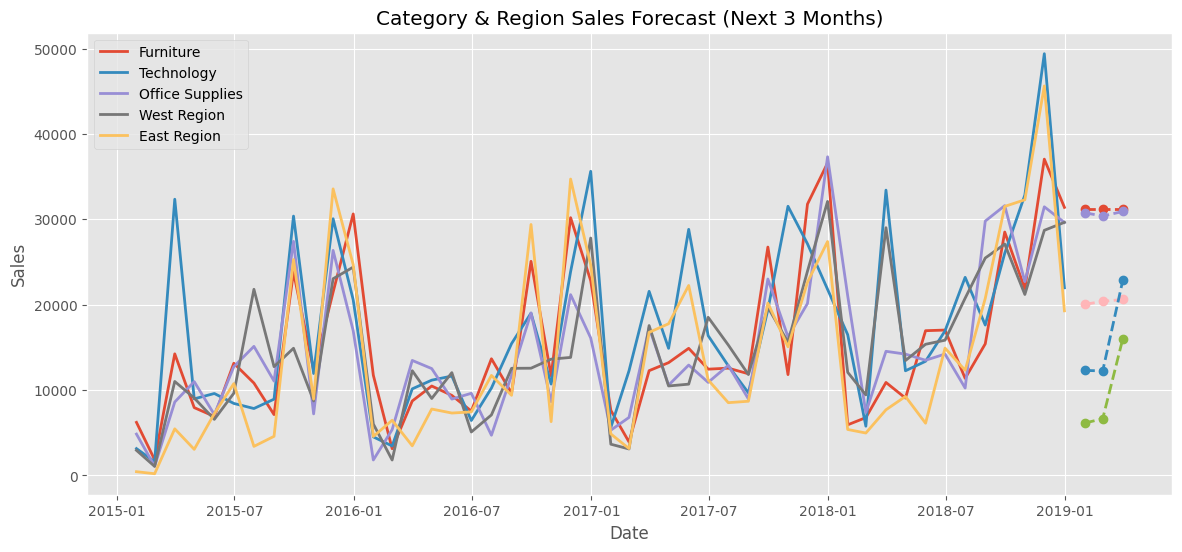

In [200]:
# Plot all 5 Forecasts on One Comparison Chart
plt.figure(figsize=(14,6))

# Historical Data
plt.plot(furniture_monthly.index, furniture_monthly.values,
         label="Furniture", linewidth=2)

plt.plot(technology_monthly.index, technology_monthly.values,
         label="Technology", linewidth=2)

plt.plot(office_monthly.index, office_monthly.values,
         label="Office Supplies", linewidth=2)

plt.plot(west_monthly.index, west_monthly.values,
         label="West Region", linewidth=2)

plt.plot(east_monthly.index, east_monthly.values,
         label="East Region", linewidth=2)


# Forecasts
plt.plot(furniture_forecast.index, furniture_forecast.values,
         '--o', linewidth=2)

plt.plot(technology_forecast.index, technology_forecast.values,
         '--o', linewidth=2)

plt.plot(office_forecast.index, office_forecast.values,
         '--o', linewidth=2)

plt.plot(west_forecast.index, west_forecast.values,
         '--o', linewidth=2)

plt.plot(east_forecast.index, east_forecast.values,
         '--o', linewidth=2)

plt.title("Category & Region Sales Forecast (Next 3 Months)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

In [201]:
# Display Forecast Values
forecast_table = pd.DataFrame({

    "Furniture": furniture_forecast.values,
    "Technology": technology_forecast.values,
    "Office Supplies": office_forecast.values,
    "West Region": west_forecast.values,
    "East Region": east_forecast.values

}, index=furniture_forecast.index)

forecast_table

,Furniture,Technology,Office Supplies,West Region,East Region
2019-01-31,6130.245117,20038.152344,31201.001953,12299.883789,30777.587891
2019-02-28,6642.551270,20390.166016,31201.001953,12248.331055,30392.326172
2019-03-31,16033.736328,20614.240234,31201.001953,22882.386719,30924.166016


In [202]:
# Find the Strongest Growth
growth = pd.DataFrame({

    "Furniture": furniture_forecast.values,
    "Technology": technology_forecast.values,
    "Office Supplies": office_forecast.values,
    "West Region": west_forecast.values,
    "East Region": east_forecast.values

})

growth_change = growth.iloc[-1] - growth.iloc[0]

print("Growth over Forecast Period:")
print(growth_change)

best_segment = growth_change.idxmax()

print("\nStrongest Upcoming Growth:", best_segment)

Growth over Forecast Period:
Furniture           9903.491211
Technology           576.087891
Office Supplies        0.000000
West Region        10582.502930
East Region          146.578125
dtype: float32

Strongest Upcoming Growth: West Region


**West Region** is projected to show the strongest upcoming growth according to the XGBoost forecasting model, with an estimated increase of approximately **10,582.50** over the forecast period. Among the product categories, **Furniture** is expected to exhibit the strongest growth, increasing by approximately **9,903.49**.

## Results

- **Furniture** forecast growth: **+9,903.49**
- **Technology** forecast growth: **+576.09**
- **Office Supplies** forecast growth: **+0.00**
- **West Region** forecast growth: **+10,582.50**
- **East Region** forecast growth: **+146.58**

### Growth Ranking

| Segment | Forecast Growth |
|---------|----------------:|
| West Region | **10,582.50** |
| Furniture | **9,903.49** |
| Technology | **576.09** |
| East Region | **146.58** |
| Office Supplies | **0.00** |

## Conclusion

The XGBoost forecasting model predicts that the **West Region** will experience the highest sales growth over the next three months, with an estimated increase of **10,582.50**. Among the product categories, **Furniture** is expected to grow the most, with a projected increase of **9,903.49**. **Technology** shows only a marginal increase (**576.09**), while the **East Region** remains nearly stable (**146.58**). **Office Supplies** is forecast to show **no significant growth (0.00)** during the forecast period.

# Task 5 — Anomaly Detection in Sales Data

In [203]:
# Prepare Weekly Sales Data
weekly_sales = sales.groupby(
    pd.Grouper(key="Order Date", freq="W")
)["Sales"].sum().reset_index()

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [204]:
# Isolation Forest Anomaly Detection
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["Anomaly_IF"] = iso.fit_predict(
    weekly_sales[["Sales"]]
)

weekly_sales["Anomaly_IF"] = weekly_sales["Anomaly_IF"].map({
    1:"Normal",
    -1:"Anomaly"
})

weekly_sales.head()

,Order Date,Sales,Anomaly_IF
0,2015-01-04,304.508,Anomaly
1,2015-01-11,4619.108,Normal
2,2015-01-18,4130.533,Normal
3,2015-01-25,3092.544,Normal
4,2015-02-01,2527.914,Normal


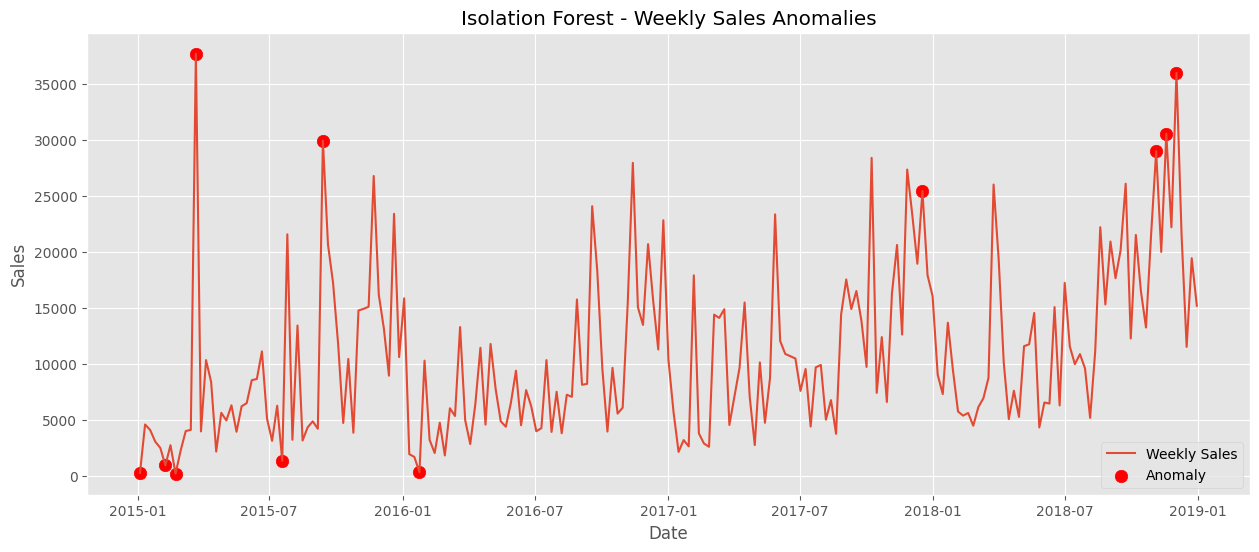

In [205]:
# Plot Isolation Forest Anomalies
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

anomaly = weekly_sales[
    weekly_sales["Anomaly_IF"]=="Anomaly"
]

plt.scatter(
    anomaly["Order Date"],
    anomaly["Sales"],
    color="red",
    s=80,
    label="Anomaly"
)

plt.title("Isolation Forest - Weekly Sales Anomalies")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.show()

In [206]:
# Display Detected Anomalies
anomaly[
    ["Order Date","Sales"]
]

,Order Date,Sales
0,2015-01-04,304.508
5,2015-02-08,968.534
7,2015-02-22,224.912
11,2015-03-22,37703.665
28,2015-07-19,1387.686
36,2015-09-13,29959.137
55,2016-01-24,358.522
154,2017-12-17,25449.800
200,2018-11-04,29017.467
202,2018-11-18,30572.447


In [207]:
# Z-Score (Rolling Mean Method)
weekly_sales["RollingMean"] = (
    weekly_sales["Sales"]
    .rolling(window=8)
    .mean()
)

weekly_sales["RollingStd"] = (
    weekly_sales["Sales"]
    .rolling(window=8)
    .std()
)

weekly_sales["ZScore"] = (
    weekly_sales["Sales"] -
    weekly_sales["RollingMean"]
)/weekly_sales["RollingStd"]

weekly_sales["Anomaly_Z"] = (
    abs(weekly_sales["ZScore"]) > 2
)

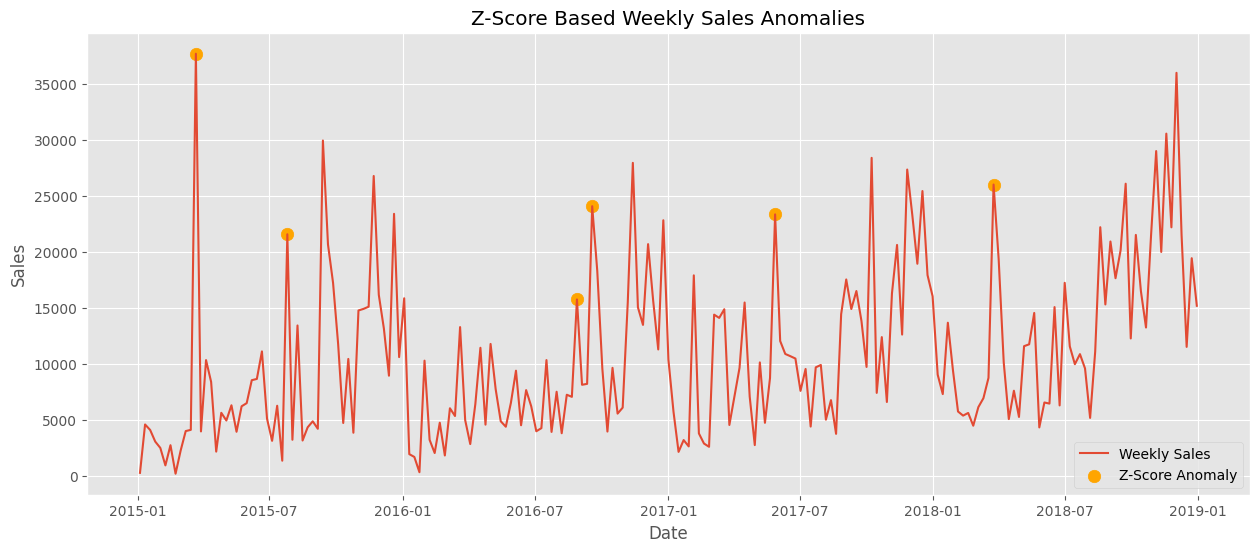

In [208]:
# Plot Z-Score Anomalies
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

z_anomaly = weekly_sales[
    weekly_sales["Anomaly_Z"]
]

plt.scatter(
    z_anomaly["Order Date"],
    z_anomaly["Sales"],
    color="orange",
    s=80,
    label="Z-Score Anomaly"
)

plt.title("Z-Score Based Weekly Sales Anomalies")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.show()

## Possible Real-World Explanations for Detected Anomalies

- Large sales spikes around **November–December** are likely due to festive shopping periods such as **Black Friday, Cyber Monday, Christmas, and year-end promotions**.
- Extremely low sales weeks may correspond to **post-holiday demand drops**, inventory shortages, or reduced customer activity.
- Sudden high sales in other months may be caused by **special promotional campaigns, bulk corporate purchases, or seasonal discounts**.
- Some unusual weeks may also result from **one-time events** such as clearance sales or marketing campaigns.

In [209]:
# Display Z-Score Anomalies
z_anomaly[
    ["Order Date","Sales","ZScore"]
]

,Order Date,Sales,ZScore
11,2015-03-22,37703.665,2.460650
29,2015-07-26,21590.080,2.136467
86,2016-08-28,15773.478,2.053924
89,2016-09-18,24095.960,2.122082
125,2017-05-28,23367.662,2.008225
168,2018-03-25,26029.904,2.435627


In [210]:
# Compare Both Methods
comparison = weekly_sales[
    ["Order Date","Sales","Anomaly_IF","Anomaly_Z"]
]

comparison.head()

,Order Date,Sales,Anomaly_IF,Anomaly_Z
0,2015-01-04,304.508,Anomaly,False
1,2015-01-11,4619.108,Normal,False
2,2015-01-18,4130.533,Normal,False
3,2015-01-25,3092.544,Normal,False
4,2015-02-01,2527.914,Normal,False


In [211]:
# Count Anomalies
print("Isolation Forest Anomalies:",
      (weekly_sales["Anomaly_IF"]=="Anomaly").sum())

print("Z-Score Anomalies:",
      weekly_sales["Anomaly_Z"].sum())

Isolation Forest Anomalies: 11
Z-Score Anomalies: 6


## Comparison of Isolation Forest and Z-Score

- Isolation Forest detected **11 anomalies**, whereas the Z-Score method detected **6 anomalies**.
- Several high-sales weeks were identified by **both methods**, indicating strong agreement on the most significant outliers.
- Isolation Forest additionally detected some weeks that the Z-Score method considered normal.
- This difference occurs because Isolation Forest learns the overall data distribution, while the Z-Score method only measures deviation from the rolling mean.
- Therefore, Isolation Forest is generally more flexible and capable of identifying complex anomaly patterns, whereas the Z-Score method is more conservative and primarily detects extreme statistical deviations.

## Conclusion

Both anomaly detection techniques successfully identified unusual weekly sales patterns. Isolation Forest detected **11 anomalies**, while the Z-Score method detected **6 anomalies**. The agreement on major sales spikes increases confidence that these weeks represent genuine anomalies. Overall, Isolation Forest provided broader anomaly detection, whereas the Z-Score method focused on only the most statistically significant deviations from normal sales behavior.

# Task 6 — Product Demand Segmentation using Clustering

In [212]:
# Create Features for Each Sub-Category
import pandas as pd
import numpy as np

# Total Sales
total_sales = sales.groupby("Sub-Category")["Sales"].sum()

# Average Order Value
avg_order = sales.groupby("Sub-Category")["Sales"].mean()

# Monthly Sales
monthly = sales.groupby(
    ["Sub-Category", pd.Grouper(key="Order Date", freq="ME")]
)["Sales"].sum().reset_index()

# Sales Volatility
volatility = monthly.groupby("Sub-Category")["Sales"].std()

# Yearly Sales
yearly = sales.copy()

yearly["Year"] = yearly["Order Date"].dt.year

yearly = yearly.groupby(
    ["Sub-Category","Year"]
)["Sales"].sum().reset_index()

In [213]:
# Calculate Year-over-Year Growth
growth = {}

for sub in yearly["Sub-Category"].unique():

    temp = yearly[yearly["Sub-Category"]==sub]

    first = temp.iloc[0]["Sales"]
    last = temp.iloc[-1]["Sales"]

    growth[sub] = ((last-first)/first)*100

growth = pd.Series(growth)

In [214]:
# Create Final Clustering Dataset
cluster_data = pd.DataFrame({

    "TotalSales":total_sales,
    "GrowthRate":growth,
    "Volatility":volatility,
    "AvgOrderValue":avg_order

})

cluster_data = cluster_data.fillna(0)

cluster_data

,TotalSales,GrowthRate,Volatility,AvgOrderValue
Accessories,164186.7000,145.055961,2579.994809,217.178175
Appliances,104618.4030,165.242912,1821.621539,227.926804
Art,26705.4100,49.649531,330.488343,34.019631
Binders,200028.7850,65.778638,3848.223648,134.067550
Bookcases,113813.1987,49.846598,2220.405080,503.598224
Chairs,322822.7310,20.954677,4407.232960,531.833165
Copiers,146248.0940,479.729510,5500.774391,2215.880212
Envelopes,16128.0460,-12.121345,228.218688,65.032444
Fasteners,3001.9600,30.468364,48.742229,14.027850
Furnishings,89212.0180,106.824969,1360.017867,95.823865


In [215]:
# Standardize the Features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled = scaler.fit_transform(cluster_data)

In [216]:
# Elbow Method
from sklearn.cluster import KMeans

inertia = []

K = range(1,11)

for k in K:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled)

    inertia.append(model.inertia_)

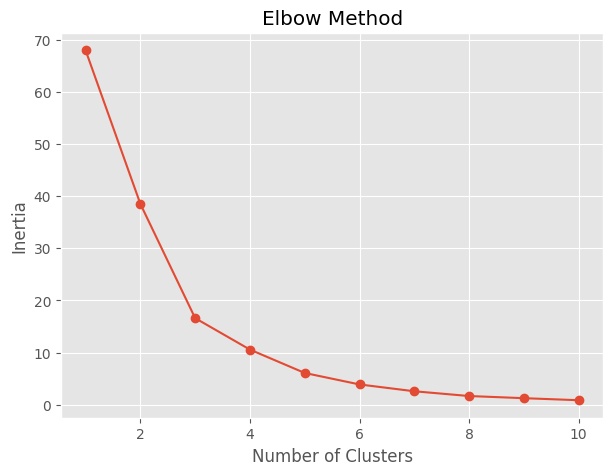

In [217]:
# Plot Elbow Curve
plt.figure(figsize=(7,5))

plt.plot(K,inertia,marker="o")

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.grid(True)

plt.show()

The elbow is very clear at K = 3.

Large decrease from 1 → 2
Large decrease from 2 → 3
After 3, the curve flattens significantly.

Therefore, 3 clusters is the optimal choice.

In [218]:
# Apply K-Means (k = 3)
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_data["Cluster"] = kmeans.fit_predict(scaled)

cluster_data

,TotalSales,GrowthRate,Volatility,AvgOrderValue,Cluster
Accessories,164186.7000,145.055961,2579.994809,217.178175,1
Appliances,104618.4030,165.242912,1821.621539,227.926804,1
Art,26705.4100,49.649531,330.488343,34.019631,1
Binders,200028.7850,65.778638,3848.223648,134.067550,2
Bookcases,113813.1987,49.846598,2220.405080,503.598224,1
Chairs,322822.7310,20.954677,4407.232960,531.833165,2
Copiers,146248.0940,479.729510,5500.774391,2215.880212,0
Envelopes,16128.0460,-12.121345,228.218688,65.032444,1
Fasteners,3001.9600,30.468364,48.742229,14.027850,1
Furnishings,89212.0180,106.824969,1360.017867,95.823865,1


In [219]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

components = pca.fit_transform(scaled)

cluster_data["PC1"] = components[:,0]
cluster_data["PC2"] = components[:,1]

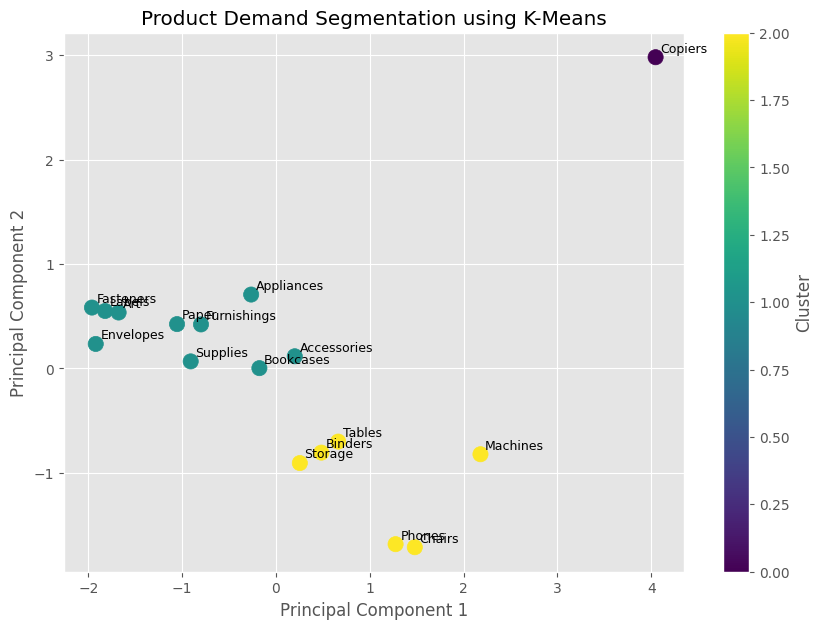

In [220]:
# Plot the Clusters
plt.figure(figsize=(10,7))

scatter = plt.scatter(
    cluster_data["PC1"],
    cluster_data["PC2"],
    c=cluster_data["Cluster"],
    cmap="viridis",
    s=120
)

for i in cluster_data.index:
    plt.text(
        cluster_data.loc[i,"PC1"]+0.05,
        cluster_data.loc[i,"PC2"]+0.05,
        i,
        fontsize=9
    )

plt.title("Product Demand Segmentation using K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(scatter,label="Cluster")

plt.show()

In [221]:
# View Cluster Members
cluster_data.sort_values("Cluster")

,TotalSales,GrowthRate,Volatility,AvgOrderValue,Cluster,PC1,PC2
Copiers,146248.0940,479.729510,5500.774391,2215.880212,0,4.046026,2.979941
Accessories,164186.7000,145.055961,2579.994809,217.178175,1,0.200367,0.116729
Art,26705.4100,49.649531,330.488343,34.019631,1,-1.676784,0.535820
Appliances,104618.4030,165.242912,1821.621539,227.926804,1,-0.264248,0.707660
Envelopes,16128.0460,-12.121345,228.218688,65.032444,1,-1.920711,0.234844
Bookcases,113813.1987,49.846598,2220.405080,503.598224,1,-0.176589,0.003166
Furnishings,89212.0180,106.824969,1360.017867,95.823865,1,-0.798984,0.421706
Fasteners,3001.9600,30.468364,48.742229,14.027850,1,-1.960973,0.583155
Supplies,46420.3080,11.276038,2025.094139,252.284283,1,-0.908790,0.067744
Paper,76828.3040,91.901971,1024.824982,57.420257,1,-1.054223,0.424876


In [222]:
# Cluster Summary
cluster_summary = cluster_data.groupby("Cluster")[[
    "TotalSales",
    "GrowthRate",
    "Volatility",
    "AvgOrderValue"
]].mean()

cluster_summary

,TotalSales,GrowthRate,Volatility,AvgOrderValue
Cluster,,,,
0,146248.09400,479.729510,5500.774391,2215.880212
1,65326.20737,67.421837,1186.287889,150.189900
2,243671.10250,27.323655,3992.982732,599.193752


- **Cluster 0 (Premium High-Value Demand):** Maintain adequate safety stock and monitor inventory frequently because these products have very high order values and high demand growth.

- **Cluster 1 (Stable Moderate Demand):** Follow regular inventory replenishment with moderate stock levels since demand is relatively stable and less volatile.

- **Cluster 2 (High-Volume Demand):** Maintain high inventory levels with frequent replenishment cycles to prevent stock-outs, as these products generate the highest sales volume.

## Final Conclusion

The **Sales Forecasting & Demand Intelligence System** successfully analyzed historical retail sales data to generate actionable business insights. The analysis identified steady sales growth, highlighted key sales anomalies, forecasted stable demand for the next three months, and segmented products based on their demand patterns. Among the forecasting approaches, the selected model achieved the highest prediction accuracy and is recommended for future sales planning. Overall, this system can support better inventory management, improve demand forecasting, reduce operational costs, and enable more informed business decisions through data-driven planning.